<a href="https://colab.research.google.com/github/RamyAkin/AI-Models/blob/main/FERRASaidi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and setup:


In [256]:
# ================== Imports and setup ==================
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random


from google.colab import drive
drive.mount('/content/drive')

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Paths

In [257]:
# JAFFE
train_path_jaffe = '/content/drive/MyDrive/UniWork3rdYear/JAFFE/train'
test_path_jaffe  = '/content/drive/MyDrive/UniWork3rdYear/JAFFE/test'

# CK / CK+ (your folder names)
train_path_ck = '/content/drive/MyDrive/UniWork3rdYear/CK_dataset/train'
test_path_ck  = '/content/drive/MyDrive/UniWork3rdYear/CK_dataset/test'

emotions = ['Happy', 'Sad', 'Surprise', 'Angry', 'Fear', 'Neutral']


# Loading in images


In [258]:
def load_images_from_folder(folder, label, image_size=(64, 64)):
    """
    Loads all images from `folder`, converts to grayscale,
    resizes, and flattens to 1D arrays.
    """
    images, labels = [], []
    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)
        if not os.path.isfile(path):
            continue
        img = Image.open(path)
        img = img.resize(image_size)
        if img.mode != 'L':
            img = img.convert('L')
        img_array = np.array(img)
        images.append(img_array)
        labels.append(label)
    return images, labels

# HOG feature extraction

In [259]:
def extract_hog_features(img, image_size=(64, 64)):
    """
    Extracts HOG features for a single 2D grayscale image.
    """
    img_resized = cv2.resize(img, image_size)
    feats = hog(
        img_resized,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True,
    )
    return feats

# Loading in and handling the datasets

In [260]:
def load_dataset(root_train, root_test, emotions_list):
    """
    Loads train and test sets for all emotions, returns:
    X_train, y_train, X_test, y_test, and raw test images for visualisation.
    """
    train_images, train_labels = [], []
    test_images,  test_labels  = [], []

    test_raw_images = []   # for plotting faces later
    test_raw_labels = []

    for emo in emotions_list:
        train_folder = os.path.join(root_train, emo)
        test_folder  = os.path.join(root_test, emo)

        # Train
        imgs, lbls = load_images_from_folder(train_folder, emo)
        train_images.extend(imgs)
        train_labels.extend(lbls)

        # Test
        imgs_t, lbls_t = load_images_from_folder(test_folder, emo)
        test_images.extend(imgs_t)
        test_labels.extend(lbls_t)

        # Keep raw test images for plotting
        test_raw_images.extend(imgs_t)
        test_raw_labels.extend(lbls_t)

    # HOG features
    train_hog = [extract_hog_features(img) for img in train_images]
    test_hog  = [extract_hog_features(img) for img in test_images]

    X_train = np.array(train_hog)
    y_train = np.array(train_labels)
    X_test  = np.array(test_hog)
    y_test  = np.array(test_labels)

    print(f"Loaded {len(train_images)} training and {len(test_images)} testing images.")
    print("Feature shape:", X_train.shape)

    return X_train, y_train, X_test, y_test, test_raw_images, test_raw_labels

# Plotting of confusion matrix

In [261]:
def plot_confusion_matrix(cm, classes, title):
    """
    Simple confusion matrix heatmap.
    """
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks, classes, rotation=45, ha="right")
    ax.set_yticks(tick_marks, classes)

    # Label cells
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                int(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Setup of showing three classified faces wth predicted and actual labels

In [262]:
def show_three_classified_faces(images, true_labels, pred_labels, target_emotions):
    """
    Show one correctly classified example for each of three emotions.
    """
    selected = {}
    for idx, (img, t, p) in enumerate(zip(images, true_labels, pred_labels)):
        if t == p and t in target_emotions and t not in selected:
            selected[t] = (img, p)
        if len(selected) == len(target_emotions):
            break

    if not selected:
        print("No correctly classified examples for the requested emotions.")
        return

    fig, axes = plt.subplots(1, len(selected), figsize=(4 * len(selected), 4))
    if len(selected) == 1:
        axes = [axes]

    for ax, emo in zip(axes, selected.keys()):
        img, pred = selected[emo]
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True: {emo}\nPred: {pred}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()


# Loading in JAFFE and CK datasets

In [263]:
import random

def augment_image(img):
    h, w = img.shape
    angle = random.uniform(-10, 10)
    M_rot = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    rotated = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT_101)

    tx = random.randint(-3, 3)
    ty = random.randint(-3, 3)
    M_trans = np.float32([[1, 0, tx], [0, 1, ty]])
    translated = cv2.warpAffine(rotated, M_trans, (w, h), borderMode=cv2.BORDER_REFLECT_101)

    return translated

def load_jaffe_with_augmentation(root_train, root_test, emotions_list, image_size=(64, 64), aug_factor=2):
    train_images, train_labels = [], []
    test_images,  test_labels  = [], []
    test_raw_images = []
    test_raw_labels = []

    for emo in emotions_list:
        train_folder = os.path.join(root_train, emo)
        test_folder  = os.path.join(root_test, emo)

        imgs, lbls = load_images_from_folder(train_folder, emo, image_size=image_size)
        train_images.extend(imgs)
        train_labels.extend(lbls)

        imgs_t, lbls_t = load_images_from_folder(test_folder, emo, image_size=image_size)
        test_images.extend(imgs_t)
        test_labels.extend(lbls_t)
        test_raw_images.extend(imgs_t)
        test_raw_labels.extend(lbls_t)

    aug_images, aug_labels = [], []
    for img, label in zip(train_images, train_labels):
        for _ in range(aug_factor):
            aug_img = augment_image(img)
            aug_images.append(aug_img)
            aug_labels.append(label)

    all_train_images = train_images + aug_images
    all_train_labels = train_labels + aug_labels

    train_hog = [extract_hog_features(img) for img in all_train_images]
    test_hog  = [extract_hog_features(img) for img in test_images]

    X_train = np.array(train_hog)
    y_train = np.array(all_train_labels)
    X_test  = np.array(test_hog)
    y_test  = np.array(test_labels)

    print(f"Original JAFFE training images: {len(train_images)}")
    print(f"Augmented JAFFE training images: {len(aug_images)}")
    print(f"Total JAFFE training images: {len(all_train_images)}")
    print(f"JAFFE test images: {len(test_images)}")
    print("JAFFE feature shape:", X_train.shape)

    return X_train, y_train, X_test, y_test, test_raw_images, test_raw_labels

print("=== JAFFE dataset (with augmentation) ===")
X_train_jaffe, y_train_jaffe, X_test_jaffe, y_test_jaffe, jaffe_test_raw, jaffe_test_raw_labels = \
    load_jaffe_with_augmentation(train_path_jaffe, test_path_jaffe, emotions, image_size=(64, 64), aug_factor=2)

print("\n=== CK dataset ===")
X_train_ck, y_train_ck, X_test_ck, y_test_ck, ck_test_raw, ck_test_raw_labels = \
    load_dataset(train_path_ck, test_path_ck, emotions)


print("\n=== CK dataset ===")
X_train_ck, y_train_ck, X_test_ck, y_test_ck, ck_test_raw, ck_test_raw_labels = \
    load_dataset(train_path_ck, test_path_ck, emotions)


=== JAFFE dataset (with augmentation) ===
Original JAFFE training images: 95
Augmented JAFFE training images: 190
Total JAFFE training images: 285
JAFFE test images: 65
JAFFE feature shape: (285, 1764)

=== CK dataset ===
Loaded 342 training and 145 testing images.
Feature shape: (342, 1764)

=== CK dataset ===
Loaded 342 training and 145 testing images.
Feature shape: (342, 1764)


# Defining SVM pipeline

In [264]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define base pipeline (same as before)
base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(class_weight="balanced", random_state=42)),
])

# Hyperparameter grid: small and safe
param_grid = {
    "svm__kernel": ["linear", "rbf"],
    "svm__C": [0.1, 1, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Training, testing, and evaluation against JAFFE

=== Hyperparameter tuning: JAFFE ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best JAFFE params: {'svm__C': 0.1, 'svm__kernel': 'linear'}
Best JAFFE CV accuracy: 0.7578947368421053
JAFFE tuned test accuracy: 0.7385

Classification report (JAFFE tuned):
              precision    recall  f1-score   support

       Happy       0.90      0.90      0.90        10
         Sad       1.00      0.42      0.59        12
    Surprise       1.00      0.45      0.62        11
       Angry       0.50      0.91      0.65        11
        Fear       1.00      0.83      0.91        12
     Neutral       0.60      1.00      0.75         9

    accuracy                           0.74        65
   macro avg       0.83      0.75      0.74        65
weighted avg       0.84      0.74      0.73        65

Confusion matrix (JAFFE tuned):
[[ 5  0  0  0  0  6]
 [ 0 10  1  0  0  1]
 [ 0  0  9  0  0  0]
 [ 0  0  0  9  0  1]
 [ 0  0  4  1  5  2]
 [ 0  0  1  0  0 10]]


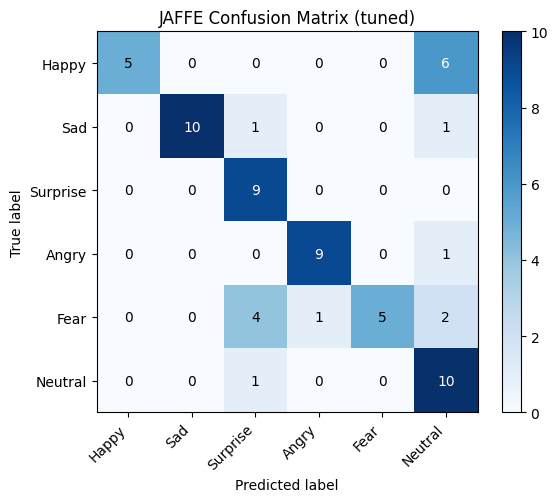

In [265]:
print("=== Hyperparameter tuning: JAFFE ===")
grid_jaffe = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_jaffe.fit(X_train_jaffe, y_train_jaffe)

print("Best JAFFE params:", grid_jaffe.best_params_)
print("Best JAFFE CV accuracy:", grid_jaffe.best_score_)

best_jaffe_model = grid_jaffe.best_estimator_
y_pred_jaffe_tuned = best_jaffe_model.predict(X_test_jaffe)
acc_jaffe_tuned = accuracy_score(y_test_jaffe, y_pred_jaffe_tuned)
print(f"JAFFE tuned test accuracy: {acc_jaffe_tuned:.4f}\n")

print("Classification report (JAFFE tuned):")
print(classification_report(y_test_jaffe, y_pred_jaffe_tuned, target_names=emotions))

cm_jaffe_tuned = confusion_matrix(y_test_jaffe, y_pred_jaffe_tuned, labels=emotions)
print("Confusion matrix (JAFFE tuned):")
print(cm_jaffe_tuned)
plot_confusion_matrix(cm_jaffe_tuned, classes=emotions, title="JAFFE Confusion Matrix (tuned)")



# Training, testing, and evaluation against CK


=== Hyperparameter tuning: CK ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best CK params: {'svm__C': 10, 'svm__kernel': 'rbf'}
Best CK CV accuracy: 0.66692242114237
CK tuned test accuracy: 0.6483

Classification report (CK tuned):
              precision    recall  f1-score   support

       Happy       0.50      0.30      0.38        20
         Sad       1.00      0.43      0.60         7
    Surprise       0.89      0.86      0.88        29
       Angry       0.49      0.71      0.58        41
        Fear       0.50      0.32      0.39        19
     Neutral       0.81      0.86      0.83        29

    accuracy                           0.65       145
   macro avg       0.70      0.58      0.61       145
weighted avg       0.66      0.65      0.64       145

Confusion matrix (CK tuned):
[[25  0  0  0  0  4]
 [ 0  6  2  3  0  8]
 [ 0  0 25  0  0  4]
 [ 0  1  0  6  0 13]
 [ 0  3  0  0  3  1]
 [ 3  2  4  3  0 29]]


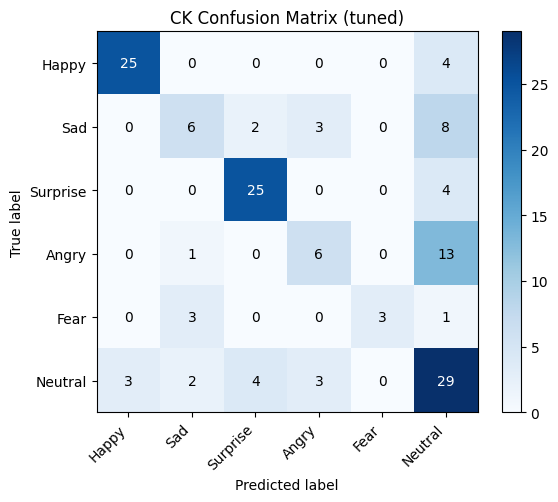

In [266]:
print("\n=== Hyperparameter tuning: CK ===")
grid_ck = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_ck.fit(X_train_ck, y_train_ck)

print("Best CK params:", grid_ck.best_params_)
print("Best CK CV accuracy:", grid_ck.best_score_)

best_ck_model = grid_ck.best_estimator_
y_pred_ck_tuned = best_ck_model.predict(X_test_ck)
acc_ck_tuned = accuracy_score(y_test_ck, y_pred_ck_tuned)
print(f"CK tuned test accuracy: {acc_ck_tuned:.4f}\n")

print("Classification report (CK tuned):")
print(classification_report(y_test_ck, y_pred_ck_tuned, target_names=emotions))

cm_ck_tuned = confusion_matrix(y_test_ck, y_pred_ck_tuned, labels=emotions)
print("Confusion matrix (CK tuned):")
print(cm_ck_tuned)
plot_confusion_matrix(cm_ck_tuned, classes=emotions, title="CK Confusion Matrix (tuned)")


# Setup of train/test bars

In [267]:
from sklearn.metrics import classification_report

def plot_per_class_f1(y_true, y_pred, classes, title):
    """
    Plot per-class F1-scores for a given dataset.
    """
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    f1_scores = [report[c]['f1-score'] for c in classes]

    x = np.arange(len(classes))

    plt.figure(figsize=(8, 4))
    plt.bar(x, f1_scores, color='skyblue')
    plt.xticks(x, classes, rotation=45, ha='right')
    plt.ylim(0, 1.0)
    plt.ylabel('F1-score')
    plt.title(title)
    for i, v in enumerate(f1_scores):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
    plt.tight_layout()
    plt.show()


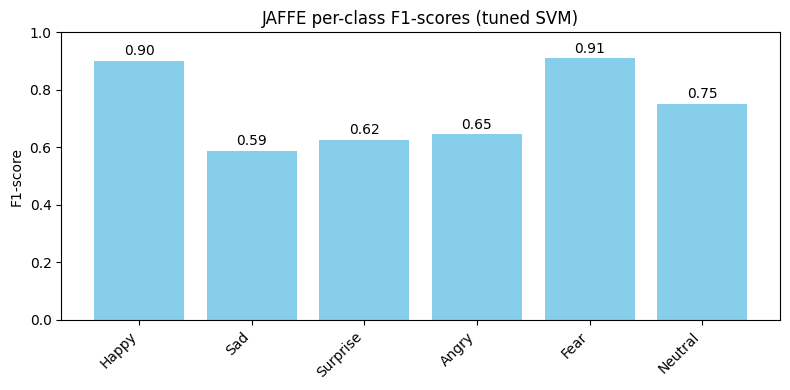

In [268]:
# JAFFE tuned F1 bar chart
plot_per_class_f1(
    y_test_jaffe,
    y_pred_jaffe_tuned,
    emotions,
    title="JAFFE per-class F1-scores (tuned SVM)"
)

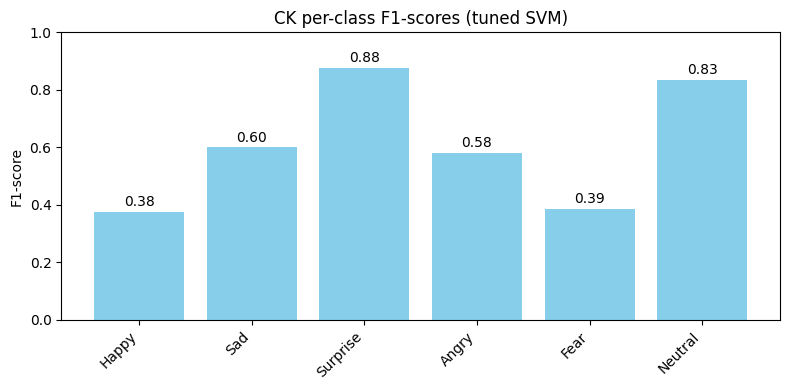

In [269]:
# CK tuned F1 bar chart
plot_per_class_f1(
    y_test_ck,
    y_pred_ck_tuned,
    emotions,
    title="CK per-class F1-scores (tuned SVM)"
)

# Display of 3 faces with correct classification

=== Example correctly classified faces (JAFFE tuned) ===


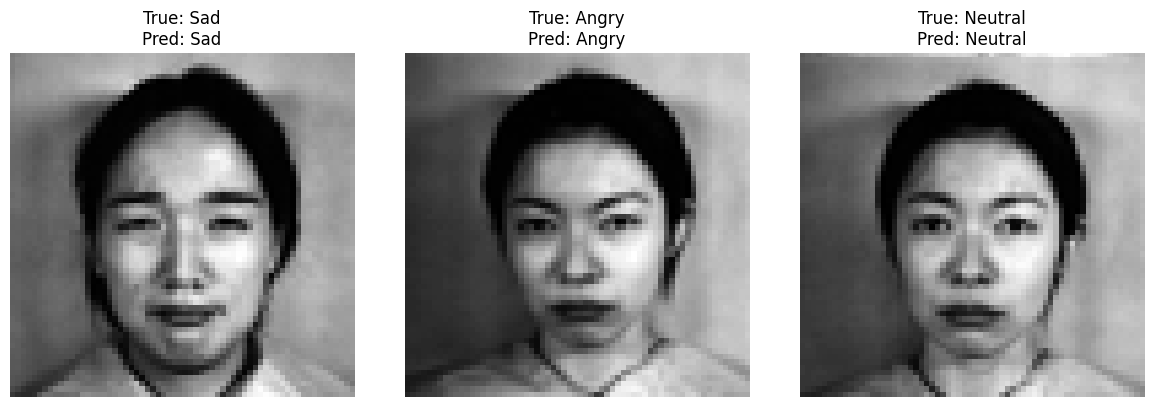

=== Example correctly classified faces (CK tuned) ===


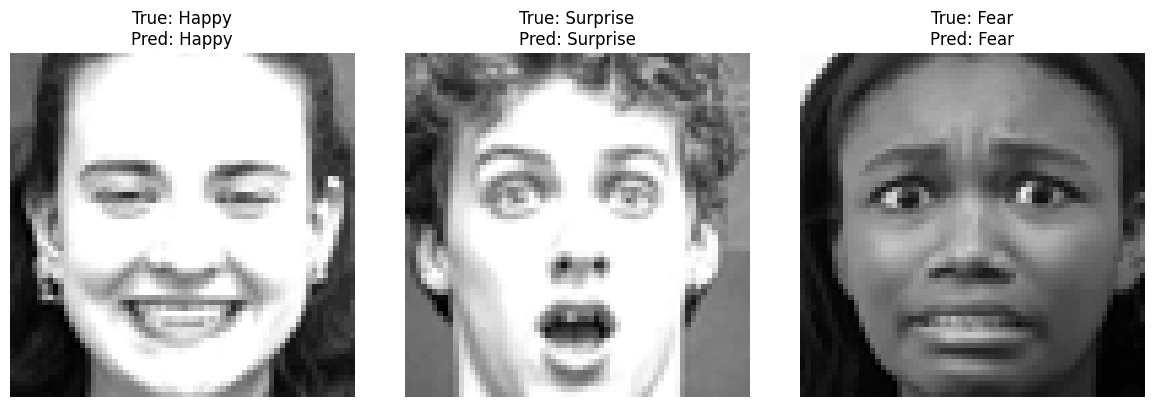

In [270]:
# JAFFE: three correctly classified faces (using tuned model)
print("=== Example correctly classified faces (JAFFE tuned) ===")
show_three_classified_faces(
    jaffe_test_raw,          # raw 2D test images for JAFFE
    y_test_jaffe,            # true JAFFE labels
    y_pred_jaffe_tuned,      # predictions from best_jaffe_model
    target_emotions=['Angry', 'Sad', 'Neutral']  # choose any three
)

# CK: three correctly classified faces (using tuned model)
print("=== Example correctly classified faces (CK tuned) ===")
show_three_classified_faces(
    ck_test_raw,             # raw 2D test images for CK
    y_test_ck,               # true CK labels
    y_pred_ck_tuned,         # predictions from best_ck_model
    target_emotions=['Happy', 'Fear', 'Surprise']
)


# Final comparative printout

In [271]:
print("\n=== Comparative Summary ===")
print(f"JAFFE test accuracy: {acc_jaffe_tuned:.4f}")
print(f"CK test accuracy:    {acc_ck_tuned:.4f}")
if acc_jaffe_tuned > acc_ck_tuned:
    print("The model performed better on the JAFFE dataset in this instance.")
elif acc_ck_tuned > acc_jaffe_tuned:
    print("The model performed better on the CK dataset in this instance.")
else:
    print("The model performed equally well on both datasets in this instance.")


=== Comparative Summary ===
JAFFE test accuracy: 0.7385
CK test accuracy:    0.6483
The model performed better on the JAFFE dataset in this instance.
